<a href="https://colab.research.google.com/github/bhakti-1304/Bhakti.github.io/blob/main/ABG_Motors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


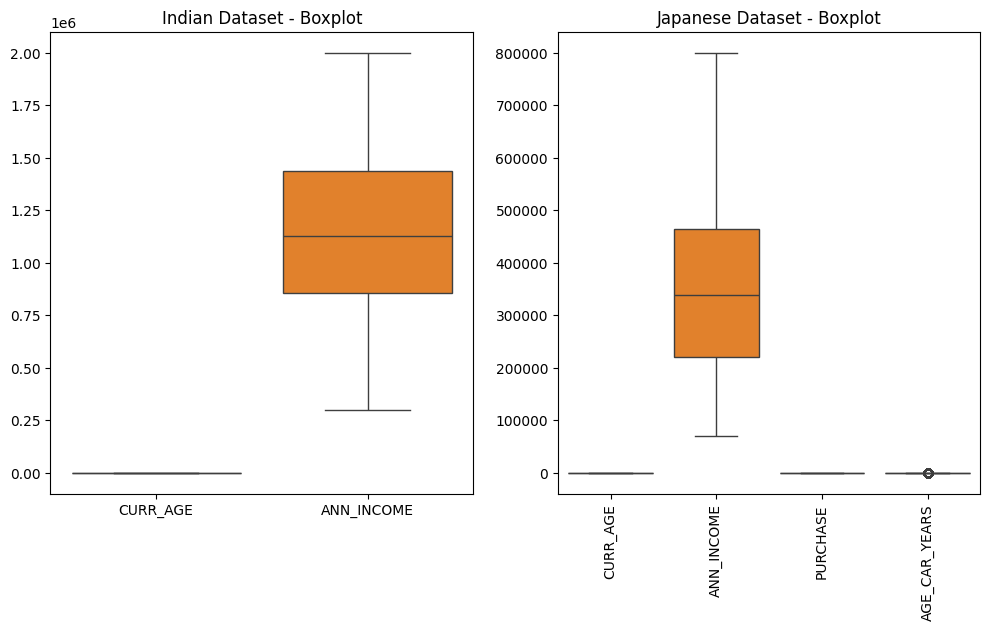


📊 Outliers Count in Indian Dataset:
{'CURR_AGE': 0, 'ANN_INCOME': 0}

📊 Outliers Count in Japanese Dataset:
{'CURR_AGE': 0, 'ANN_INCOME': 0, 'PURCHASE': 0, 'AGE_CAR_YEARS': 2638}


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

indian_data_path = "/content/Indian_Dataset_Cleaned.xlsx"
japanese_data_path = "/content/Japanese_Dataset_Cleaned.xlsx"

indian_df = pd.read_excel(indian_data_path)
japanese_df = pd.read_excel(japanese_data_path)

# Selecting numerical columns only
num_cols_indian = indian_df.select_dtypes(include=["number"])
num_cols_japanese = japanese_df.select_dtypes(include=["number"])

# Boxplot to visualize outliers
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=num_cols_indian)
plt.title("Indian Dataset - Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(data=num_cols_japanese)
plt.title("Japanese Dataset - Boxplot")

plt.xticks(rotation=90)
plt.show()

# IQR Method to detect outliers
def detect_outliers_iqr(df):
    outlier_counts = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = outliers.shape[0]
    return outlier_counts

outliers_indian = detect_outliers_iqr(num_cols_indian)
outliers_japanese = detect_outliers_iqr(num_cols_japanese)

print("\n📊 Outliers Count in Indian Dataset:")
print(outliers_indian)

print("\n📊 Outliers Count in Japanese Dataset:")
print(outliers_japanese)


In [5]:
# Handling outliers in the 'AGE_CAR_YEARS' feature for Japanese dataset

# Calculating the Q1, Q3, and IQR for 'AGE_CAR_YEARS' column
Q1 = japanese_df['AGE_CAR_YEARS'].quantile(0.25)
Q3 = japanese_df['AGE_CAR_YEARS'].quantile(0.75)
IQR = Q3 - Q1

# Defining lower and upper bounds for 'AGE_CAR_YEARS' feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping the values of 'AGE_CAR_YEARS' to the bounds
japanese_df['AGE_CAR_YEARS'] = japanese_df['AGE_CAR_YEARS'].clip(lower=lower_bound, upper=upper_bound)

# Checking the number of remaining outliers after handling
remaining_outliers = ((japanese_df['AGE_CAR_YEARS'] < lower_bound) | (japanese_df['AGE_CAR_YEARS'] > upper_bound)).sum()
print(f"\nRemaining outliers in 'AGE_CAR_YEARS' after handling: {remaining_outliers}")


Remaining outliers in 'AGE_CAR_YEARS' after handling: 0


**EDA**

In [6]:
#importing libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
print(indian_df.shape)
print(japanese_df.shape)

(70000, 5)
(40000, 6)


In [8]:
#summary statistics
print("\nIndian Dataset Summary Statistics:")
print(indian_df.describe())

print("\nJapanese Dataset Summary Statistics:")
print(japanese_df.describe())


Indian Dataset Summary Statistics:
           CURR_AGE    ANN_INCOME                       DT_MAINT
count  70000.000000  7.000000e+04                          70000
mean      44.995314  1.148679e+06  2018-06-28 16:10:28.662856960
min       25.000000  3.000330e+05            2016-09-14 00:00:00
25%       35.000000  8.568238e+05            2018-03-15 00:00:00
50%       45.000000  1.125152e+06            2018-07-26 00:00:00
75%       55.000000  1.438676e+06            2018-12-24 00:00:00
max       65.000000  1.999989e+06            2019-06-30 00:00:00
std       11.822122  3.994505e+05                            NaN

Japanese Dataset Summary Statistics:
          CURR_AGE     ANN_INCOME      PURCHASE  AGE_CAR_YEARS
count  40000.00000   40000.000000  40000.000000   40000.000000
mean      44.99745  359398.878225      0.575775       0.960335
std       11.82008  175109.260472      0.494231       0.496044
min       25.00000   70089.000000      0.000000       0.000000
25%       35.00000  219766

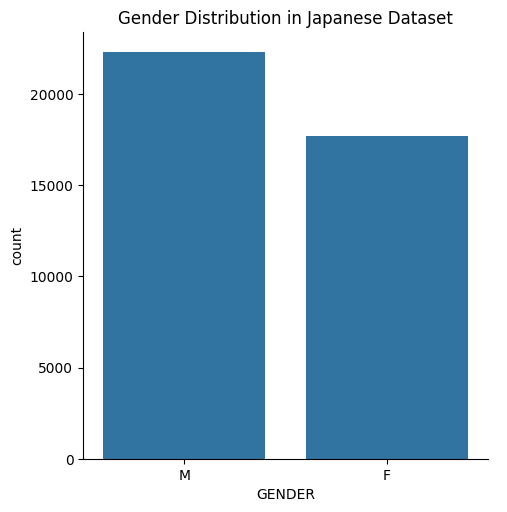

In [9]:
#gender distribution in japanese dataset
sns.catplot(data=japanese_df, x="GENDER", kind="count")
plt.title("Gender Distribution in Japanese Dataset")
plt.show()

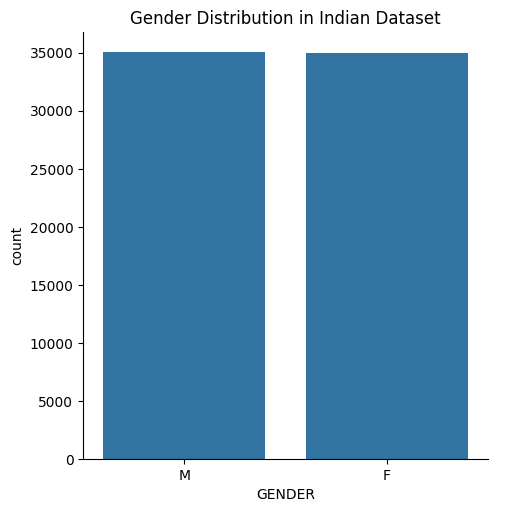

In [10]:
#gender distribution in indian dataset
sns.catplot(data=indian_df, x="GENDER", kind="count")
plt.title("Gender Distribution in Indian Dataset")
plt.show()

In [11]:
#select numerical columns for analysis
num_cols_indian = indian_df.select_dtypes(include=["number"])
num_cols_japanese = japanese_df.select_dtypes(include=["number"])


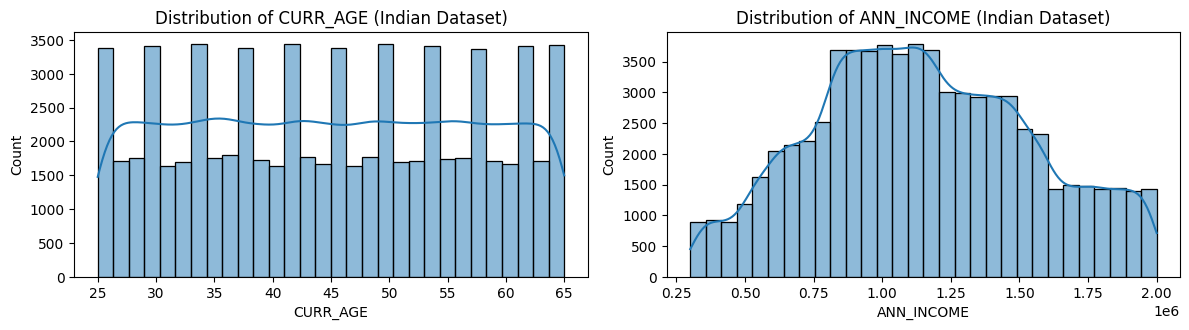

In [12]:
# Plot distributions for Indian dataset (first 4 numerical columns)
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols_indian.columns[:4]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(indian_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} (Indian Dataset)")
plt.tight_layout()
plt.show()

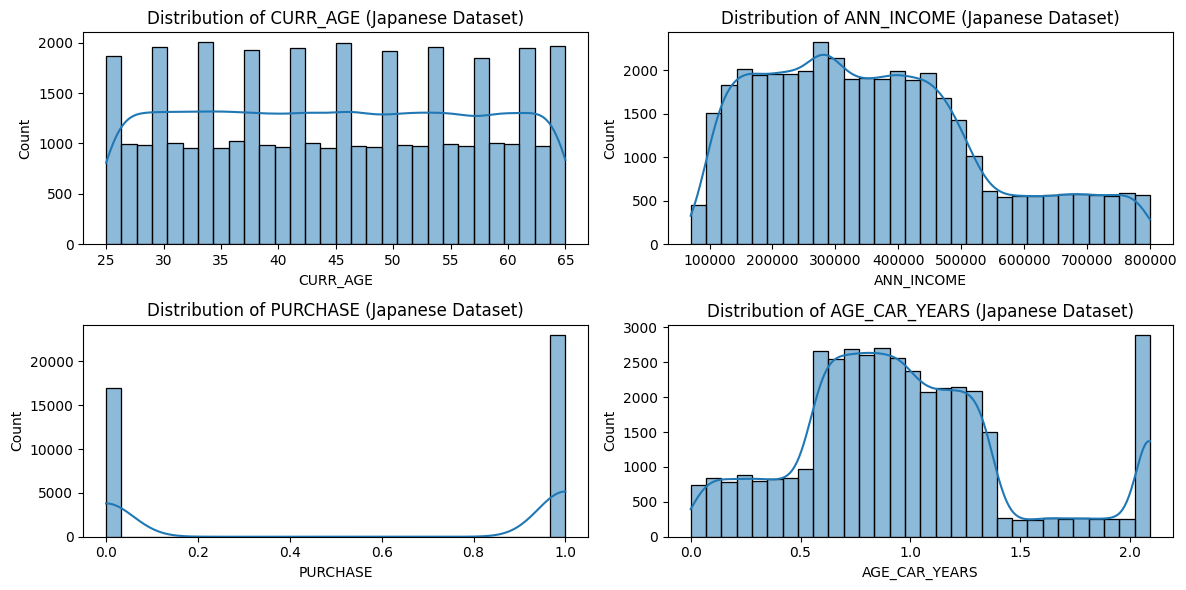

In [13]:
# Plot distributions for Japanese dataset (first 4 numerical columns)
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols_japanese.columns[:4]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(japanese_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} (Japanese Dataset)")
plt.tight_layout()
plt.show()

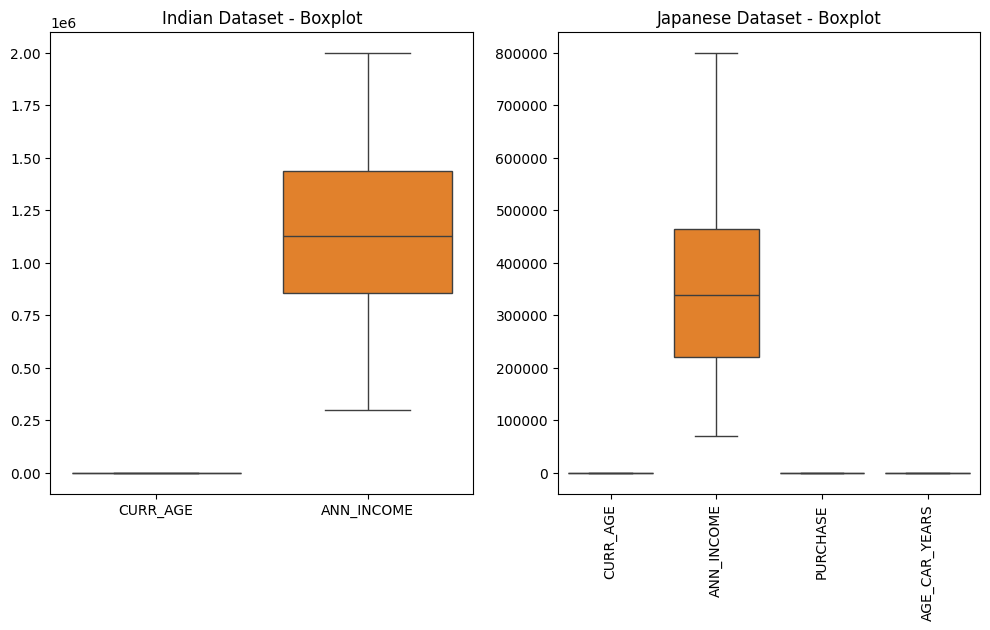

In [14]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=num_cols_indian)
plt.title("Indian Dataset - Boxplot")

plt.subplot(1, 2, 2)
sns.boxplot(data=num_cols_japanese)
plt.title("Japanese Dataset - Boxplot")

plt.xticks(rotation=90)
plt.show()


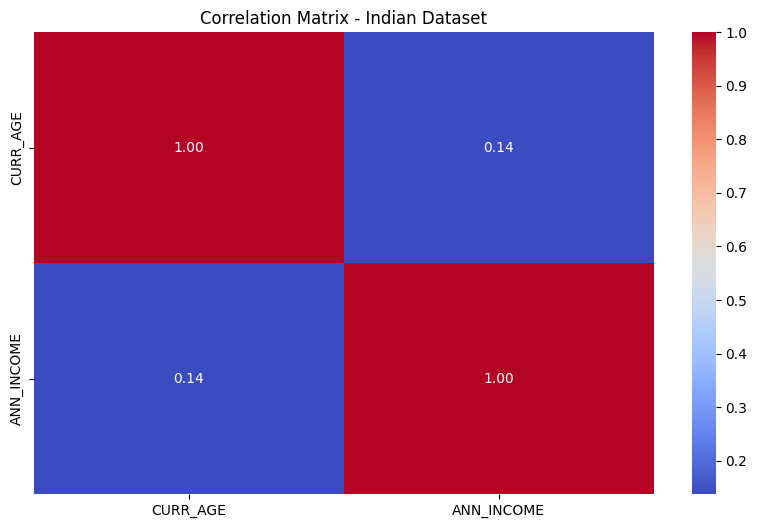

In [15]:
# Correlation heatmap for Indian dataset
plt.figure(figsize=(10, 6))
sns.heatmap(num_cols_indian.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Indian Dataset")
plt.show()

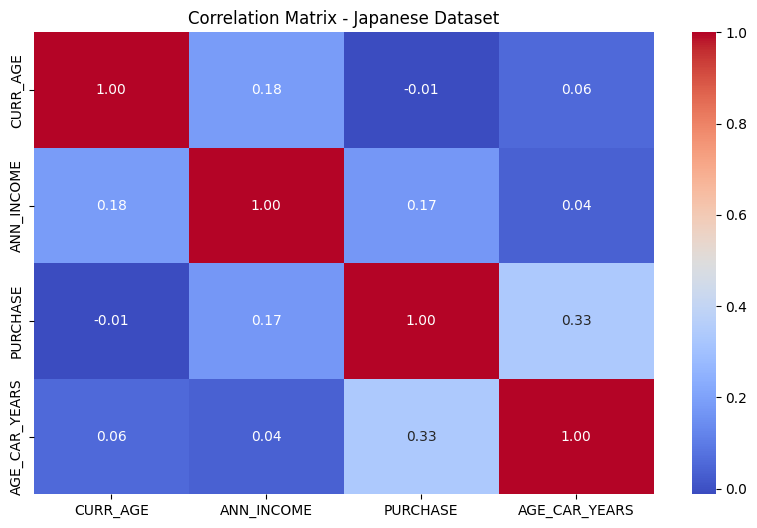

In [16]:
# Correlation heatmap for Japanese dataset
plt.figure(figsize=(10, 6))
sns.heatmap(num_cols_japanese.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Japanese Dataset")
plt.show()


In [17]:
indian_df.to_excel("/content/Indian_Dataset_Cleaned_v2.xlsx", index=False)
japanese_df.to_excel("/content/Japanese_Dataset_Cleaned_v2.xlsx", index=False)

print("\n✅ EDA and Outlier Handling Completed. Cleaned files saved.")



✅ EDA and Outlier Handling Completed. Cleaned files saved.


<h3>Feature Engineering </h3>

In [18]:
ind = pd.read_excel("/content/Indian_Dataset_Cleaned_v2.xlsx")
jap = pd.read_excel("/content/Japanese_Dataset_Cleaned_v2.xlsx")

In [19]:
print(ind.head())
print(jap.head())

           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT
0  20710B05XL        54      M     1425390 2018-04-20
1  89602T51HX        47      M     1678954 2018-06-08
2  70190Z52IP        60      M      931624 2017-07-31
3  25623V15MU        55      F     1106320 2017-07-31
4  36230I68CE        32      F      748465 2019-01-27
           ID  CURR_AGE GENDER  ANN_INCOME  PURCHASE  AGE_CAR_YEARS
0  00001Q15YJ        50      M      445344         0           1.20
1  00003I71CQ        35      M      107634         0           0.78
2  00003N47FS        59      F      502787         1           1.07
3  00005H41DE        43      M      585664         0           1.30
4  00007E17UM        39      F      705723         1           1.36


In [20]:
# Converting DT_MAINT col to similar as AGE_CAR_YEARS

# Convert DT_MAINT to datetime format
ind["DT_MAINT"] = pd.to_datetime(ind["DT_MAINT"], errors="coerce")  # Handle errors safely

# Set reference date to 2020-01-01
ref_date = pd.to_datetime("2020-01-01")

# Compute years since last maintenance
ind["MAINT_YEARS_AGO"] = (ref_date - ind["DT_MAINT"]).dt.days / 365

# Round for readability
ind["MAINT_YEARS_AGO"] = ind["MAINT_YEARS_AGO"].round(2)

print(ind.head())

           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT  MAINT_YEARS_AGO
0  20710B05XL        54      M     1425390 2018-04-20             1.70
1  89602T51HX        47      M     1678954 2018-06-08             1.57
2  70190Z52IP        60      M      931624 2017-07-31             2.42
3  25623V15MU        55      F     1106320 2017-07-31             2.42
4  36230I68CE        32      F      748465 2019-01-27             0.93


In [21]:
# Rename AGE_CAR_YEARS in jap dataset to MAINT_YEARS_AGO for consistency
jap.rename(columns={"AGE_CAR_YEARS": "MAINT_YEARS_AGO"}, inplace=True)

print(jap.head())

           ID  CURR_AGE GENDER  ANN_INCOME  PURCHASE  MAINT_YEARS_AGO
0  00001Q15YJ        50      M      445344         0             1.20
1  00003I71CQ        35      M      107634         0             0.78
2  00003N47FS        59      F      502787         1             1.07
3  00005H41DE        43      M      585664         0             1.30
4  00007E17UM        39      F      705723         1             1.36


Handling Categorical Variables

In [22]:
# Encoding 'GENDER' column (0 for Female, 1 for Male)
ind["GENDER_ENCODED"] = ind["GENDER"].map({"M": 1, "F": 0})
jap["GENDER_ENCODED"] = jap["GENDER"].map({"M": 1, "F": 0})

# Define income brackets for 'ind'
ind_income_bins = [0, ind["ANN_INCOME"].quantile(0.33), ind["ANN_INCOME"].quantile(0.66), ind["ANN_INCOME"].max()]
ind["INCOME_BRACKET"] = pd.cut(ind["ANN_INCOME"], bins=ind_income_bins, labels=["Low", "Medium", "High"])

# Define income brackets for 'jap'
jap_income_bins = [0, jap["ANN_INCOME"].quantile(0.33), jap["ANN_INCOME"].quantile(0.66), jap["ANN_INCOME"].max()]
jap["INCOME_BRACKET"] = pd.cut(jap["ANN_INCOME"], bins=jap_income_bins, labels=["Low", "Medium", "High"])

# Display first 5 rows to verify changes
print(ind[["GENDER", "GENDER_ENCODED", "INCOME_BRACKET"]].head())
print(jap[["GENDER", "GENDER_ENCODED", "INCOME_BRACKET"]].head())

  GENDER  GENDER_ENCODED INCOME_BRACKET
0      M               1           High
1      M               1           High
2      M               1            Low
3      F               0         Medium
4      F               0            Low
  GENDER  GENDER_ENCODED INCOME_BRACKET
0      M               1           High
1      M               1            Low
2      F               0           High
3      M               1           High
4      F               0           High


Scaling Numerical Features

In [23]:
from sklearn.preprocessing import MinMaxScaler

# Define the numerical features (same for both datasets now)
num_features = ["ANN_INCOME", "MAINT_YEARS_AGO"]

# Initialize the scaler
scaler = MinMaxScaler()

# Apply scaling
ind[num_features] = scaler.fit_transform(ind[num_features])
jap[num_features] = scaler.fit_transform(jap[num_features])

# Display first 5 rows to verify changes
print(ind[num_features].head())
print(jap[num_features].head())

   ANN_INCOME  MAINT_YEARS_AGO
0    0.661992         0.426523
1    0.811151         0.379928
2    0.371534         0.684588
3    0.474299         0.684588
4    0.263790         0.150538
   ANN_INCOME  MAINT_YEARS_AGO
0    0.514131         0.574163
1    0.051440         0.373206
2    0.592833         0.511962
3    0.706381         0.622010
4    0.870872         0.650718


<Axes: xlabel='MAINT_YEARS_AGO'>

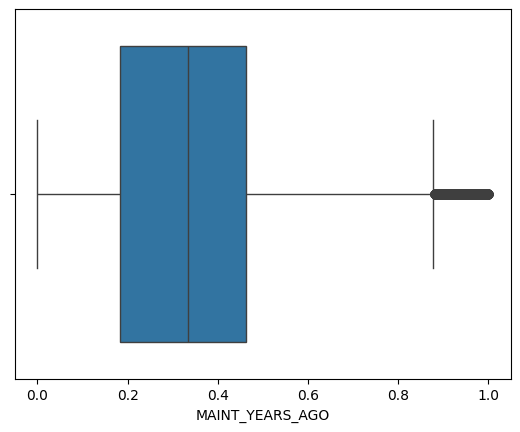

In [24]:
import seaborn as sns
sns.boxplot(x=ind["MAINT_YEARS_AGO"])

In [25]:
import numpy as np

# Find the 99th percentile
upper_limit = ind["MAINT_YEARS_AGO"].quantile(0.99)

# Cap values above this threshold
ind["MAINT_YEARS_AGO"] = np.where(ind["MAINT_YEARS_AGO"] > upper_limit, upper_limit, ind["MAINT_YEARS_AGO"])
jap["MAINT_YEARS_AGO"] = np.where(jap["MAINT_YEARS_AGO"] > upper_limit, upper_limit, jap["MAINT_YEARS_AGO"])

In [26]:
ind["MAINT_YEARS_AGO"] = ind["MAINT_YEARS_AGO"].clip(lower=lower_bound_ind, upper=upper_bound_ind)

NameError: name 'lower_bound_ind' is not defined

In [27]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1_ind = ind["MAINT_YEARS_AGO"].quantile(0.25)
Q3_ind = ind["MAINT_YEARS_AGO"].quantile(0.75)
IQR_ind = Q3_ind - Q1_ind

Q1_jap = jap["MAINT_YEARS_AGO"].quantile(0.25)
Q3_jap = jap["MAINT_YEARS_AGO"].quantile(0.75)
IQR_jap = Q3_jap - Q1_jap

# Define bounds for outliers
lower_bound_ind = Q1_ind - 1.5 * IQR_ind
upper_bound_ind = Q3_ind + 1.5 * IQR_ind

lower_bound_jap = Q1_jap - 1.5 * IQR_jap
upper_bound_jap = Q3_jap + 1.5 * IQR_jap

# Count outliers
outliers_ind = ((ind["MAINT_YEARS_AGO"] < lower_bound_ind) | (ind["MAINT_YEARS_AGO"] > upper_bound_ind)).sum()
outliers_jap = ((jap["MAINT_YEARS_AGO"] < lower_bound_jap) | (jap["MAINT_YEARS_AGO"] > upper_bound_jap)).sum()

print(f"Number of outliers in IND dataset: {outliers_ind}")
print(f"Number of outliers in JAP dataset: {outliers_jap}")


Number of outliers in IND dataset: 3166
Number of outliers in JAP dataset: 0


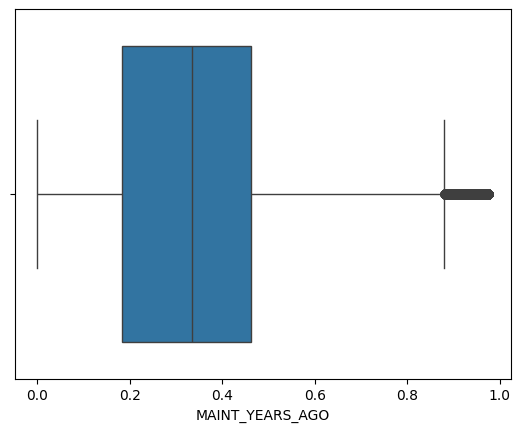

In [28]:
# Verify after capping
sns.boxplot(x=ind["MAINT_YEARS_AGO"])
plt.show()

Feature Interaction

In [29]:
# Feature Engineering
ind["INCOME_PER_YEAR"] = ind["ANN_INCOME"] / (ind["MAINT_YEARS_AGO"] + 1)
ind["AGE_MAINT_RATIO"] = ind["CURR_AGE"] / (ind["MAINT_YEARS_AGO"] + 1)

jap["INCOME_PER_YEAR"] = jap["ANN_INCOME"] / (jap["MAINT_YEARS_AGO"] + 1)
jap["AGE_MAINT_RATIO"] = jap["CURR_AGE"] / (jap["MAINT_YEARS_AGO"] + 1)

# Check new features
print(ind[["INCOME_PER_YEAR", "AGE_MAINT_RATIO"]].head())
print(jap[["INCOME_PER_YEAR", "AGE_MAINT_RATIO"]].head())

   INCOME_PER_YEAR  AGE_MAINT_RATIO
0         0.464060        37.854271
1         0.587821        34.059740
2         0.220549        35.617021
3         0.281552        32.648936
4         0.229276        27.813084
   INCOME_PER_YEAR  AGE_MAINT_RATIO
0         0.326606        31.762918
1         0.037460        25.487805
2         0.392095        39.022152
3         0.435498        26.510324
4         0.527572        23.626087


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Selecting numerical features
num_features = ["INCOME_PER_YEAR", "AGE_MAINT_RATIO"]

# Apply scaling
ind[num_features] = scaler.fit_transform(ind[num_features])
jap[num_features] = scaler.transform(jap[num_features])

# Check scaled values
print(ind[num_features].head())
print(jap[num_features].head())

   INCOME_PER_YEAR  AGE_MAINT_RATIO
0         0.452080         0.358025
1         1.102288        -0.000094
2        -0.827258         0.146878
3        -0.506765        -0.133243
4        -0.781409        -0.589639
   INCOME_PER_YEAR  AGE_MAINT_RATIO
0        -0.270062        -0.216863
1        -1.789156        -0.809093
2         0.073999         0.468247
3         0.302023        -0.712590
4         0.785756        -0.984798


Feature Selection

In [31]:
jap.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,PURCHASE,MAINT_YEARS_AGO,GENDER_ENCODED,INCOME_BRACKET,INCOME_PER_YEAR,AGE_MAINT_RATIO
0,00001Q15YJ,50,M,0.514131,0,0.574163,1,High,-0.270062,-0.216863
1,00003I71CQ,35,M,0.051440,0,0.373206,1,Low,-1.789156,-0.809093
2,00003N47FS,59,F,0.592833,1,0.511962,0,High,0.073999,0.468247
3,00005H41DE,43,M,0.706381,0,0.622010,1,High,0.302023,-0.712590
4,00007E17UM,39,F,0.870872,1,0.650718,0,High,0.785756,-0.984798


In [32]:
# Drop unnecessary columns
ind.drop(["ID", "GENDER", "INCOME_BRACKET", "DT_MAINT"], axis=1, inplace=True)
jap.drop(["ID", "GENDER", "INCOME_BRACKET"], axis=1, inplace=True)

# Verify changes
print(ind.head())
print(jap.head())

   CURR_AGE  ANN_INCOME  MAINT_YEARS_AGO  GENDER_ENCODED  INCOME_PER_YEAR  \
0        54    0.661992         0.426523               1         0.452080   
1        47    0.811151         0.379928               1         1.102288   
2        60    0.371534         0.684588               1        -0.827258   
3        55    0.474299         0.684588               0        -0.506765   
4        32    0.263790         0.150538               0        -0.781409   

   AGE_MAINT_RATIO  
0         0.358025  
1        -0.000094  
2         0.146878  
3        -0.133243  
4        -0.589639  
   CURR_AGE  ANN_INCOME  PURCHASE  MAINT_YEARS_AGO  GENDER_ENCODED  \
0        50    0.514131         0         0.574163               1   
1        35    0.051440         0         0.373206               1   
2        59    0.592833         1         0.511962               0   
3        43    0.706381         0         0.622010               1   
4        39    0.870872         1         0.650718           

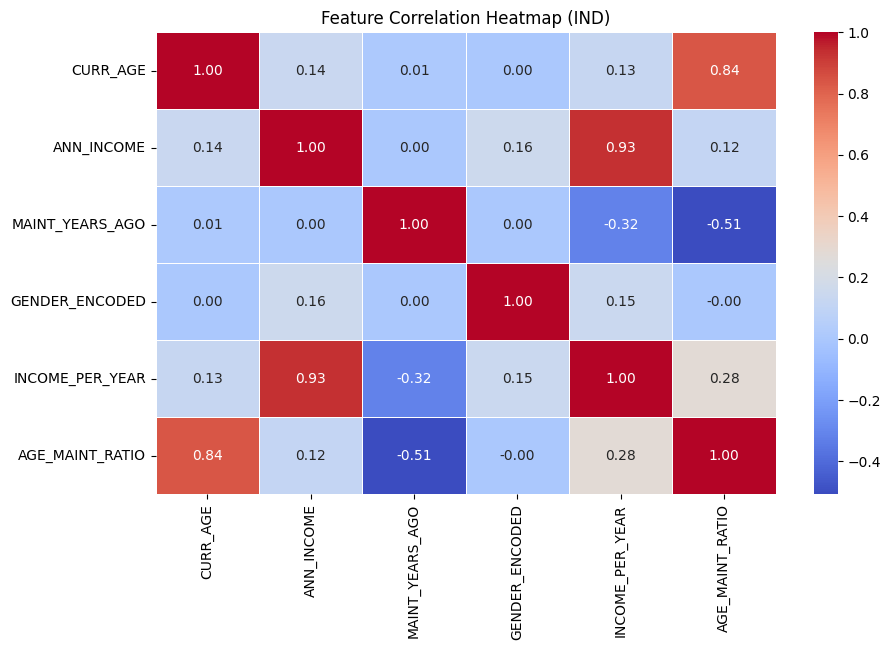

In [33]:
# Correlation Analysis (for numerical features)
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = ind.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (IND)")
plt.show()


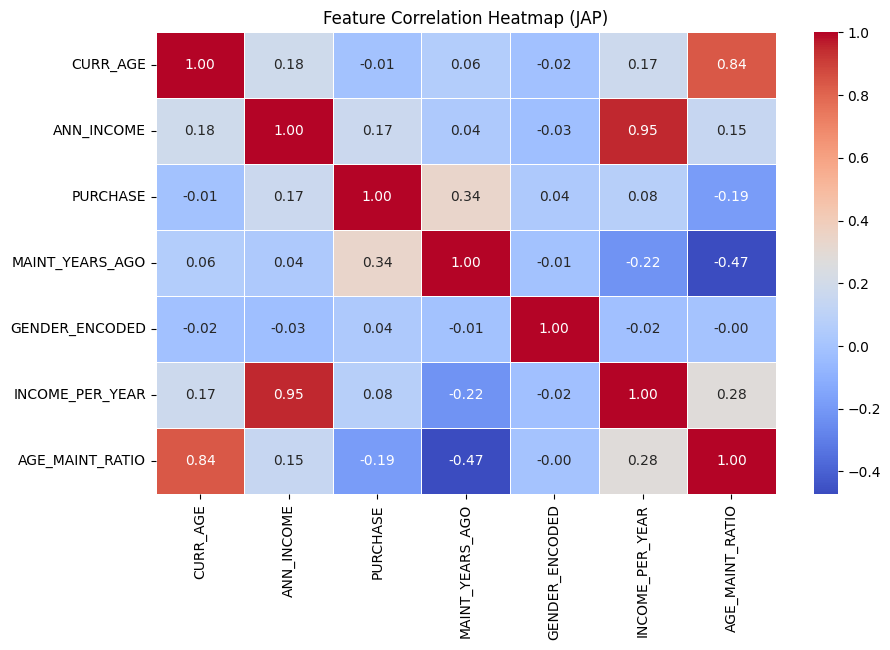

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = jap.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (JAP)")
plt.show()

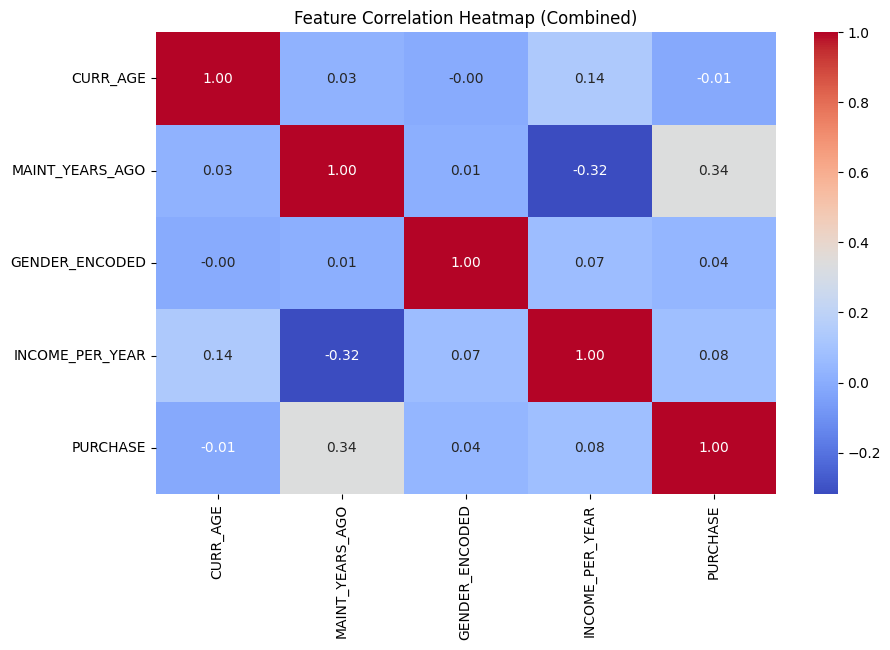

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop redundant features
drop_cols = ["ANN_INCOME", "AGE_MAINT_RATIO"]
ind_cleaned = ind.drop(columns=drop_cols)
jap_cleaned = jap.drop(columns=drop_cols)

# Combine both datasets
combined_df = pd.concat([ind_cleaned, jap_cleaned], ignore_index=True)

# Compute correlation matrix
corr_matrix = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (Combined)")
plt.show()

In [36]:
ind.head()

,CURR_AGE,ANN_INCOME,MAINT_YEARS_AGO,GENDER_ENCODED,INCOME_PER_YEAR,AGE_MAINT_RATIO
0,54,0.661992,0.426523,1,0.452080,0.358025
1,47,0.811151,0.379928,1,1.102288,-0.000094
2,60,0.371534,0.684588,1,-0.827258,0.146878
3,55,0.474299,0.684588,0,-0.506765,-0.133243
4,32,0.263790,0.150538,0,-0.781409,-0.589639


In [37]:
jap.head()

,CURR_AGE,ANN_INCOME,PURCHASE,MAINT_YEARS_AGO,GENDER_ENCODED,INCOME_PER_YEAR,AGE_MAINT_RATIO
0,50,0.514131,0,0.574163,1,-0.270062,-0.216863
1,35,0.051440,0,0.373206,1,-1.789156,-0.809093
2,59,0.592833,1,0.511962,0,0.073999,0.468247
3,43,0.706381,0,0.622010,1,0.302023,-0.712590
4,39,0.870872,1,0.650718,0,0.785756,-0.984798


In [38]:
import pandas as pd

# Define the file path for the Excel file
file_path = "final_processed_data.xlsx"

# Export both datasets to separate sheets in the same Excel file
with pd.ExcelWriter(file_path) as writer:
    ind.to_excel(writer, sheet_name="India_dataset", index=False)
    jap.to_excel(writer, sheet_name="Japan_dataset", index=False)

print(f"Datasets successfully exported to {file_path} with two sheets: 'India' & 'Japan'")


Datasets successfully exported to final_processed_data.xlsx with two sheets: 'India' & 'Japan'
